In [2]:
!pip install -q earthaccess netCDF4 h5netcdf xarray rioxarray scikit-learn \
    matplotlib seaborn pandas numpy scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.2/71.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 145.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 138.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 156.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 193.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.2.0 which is in

In [3]:
import os, glob, time, signal
from contextlib import contextmanager
from itertools import combinations
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, GroupKFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.decomposition import PCA
import earthaccess
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
PAL = sns.color_palette('colorblind')

print("Libraries loaded")

Libraries loaded


In [4]:
from google.colab import drive
drive.mount('/content/drive')

_candidates = [
    '/content/drive/MyDrive/CCN_synthesis',
    '/content/drive/My Drive/CCN_synthesis',
]
for _base in ['/content/drive/MyDrive', '/content/drive/My Drive']:
    if os.path.isdir(_base):
        _candidates += glob.glob(os.path.join(_base, '**', 'CCN_cores.csv'), recursive=True)

DATA_DIR = None
for _p in _candidates:
    _check = os.path.dirname(_p) if _p.endswith('.csv') else _p
    if os.path.isfile(os.path.join(_check, 'CCN_cores.csv')):
        DATA_DIR = _check
        break

if DATA_DIR is None:
    raise FileNotFoundError("Cannot find CCN_cores.csv — set DATA_DIR manually.")
print(f"Data path: {DATA_DIR}")

Mounted at /content/drive
Data path: /content/drive/MyDrive/CCN_synthesis


In [5]:
def clean_cols(df):
    df.columns = [c.strip().strip('"').strip('\ufeff').strip('"') for c in df.columns]
    return df

cores_all = clean_cols(pd.read_csv(f'{DATA_DIR}/CCN_cores.csv', encoding='utf-8-sig', low_memory=False))
ds_all    = clean_cols(pd.read_csv(f'{DATA_DIR}/CCN_depthseries.csv', encoding='utf-8-sig', low_memory=False))

for col in ['dry_bulk_density', 'fraction_organic_matter', 'fraction_carbon',
            'depth_min', 'depth_max']:
    if col in ds_all.columns:
        ds_all[col] = pd.to_numeric(ds_all[col], errors='coerce')

cores_all['lat'] = pd.to_numeric(cores_all['latitude'], errors='coerce')
cores_all['lon'] = pd.to_numeric(cores_all['longitude'], errors='coerce')

# ── Filter: Florida mangroves, Rovai + Doughty only ──
FOCUS_STUDIES = ['Rovai_et_al_2022', 'Doughty_et_al_2016']

mask = (
    (cores_all['country'] == 'United States') &
    (cores_all['admin_division'] == 'Florida') &
    (cores_all['habitat'] == 'mangrove') &
    (cores_all['study_id'].isin(FOCUS_STUDIES))
)
cores = cores_all[mask].copy()
core_keys = set(zip(cores['study_id'], cores['core_id']))

ds = ds_all[ds_all.set_index(['study_id', 'core_id']).index.isin(
    pd.MultiIndex.from_tuples(core_keys)
)].copy()

print(f"  Rovai + Doughty cores: {len(cores)}")
for sid in FOCUS_STUDIES:
    n = (cores['study_id'] == sid).sum()
    print(f"    {sid}: {n} cores")
print(f"  Depth intervals: {len(ds):,}")

  Rovai + Doughty cores: 44
    Rovai_et_al_2022: 27 cores
    Doughty_et_al_2016: 17 cores
  Depth intervals: 125



── Surface Carbon (top 30cm) ──
  Cores with carbon: 42
    Rovai_et_al_2022: n=27, C=[0.061, 0.382], mean=0.234
    Doughty_et_al_2016: n=15, C=[0.014, 0.395], mean=0.119


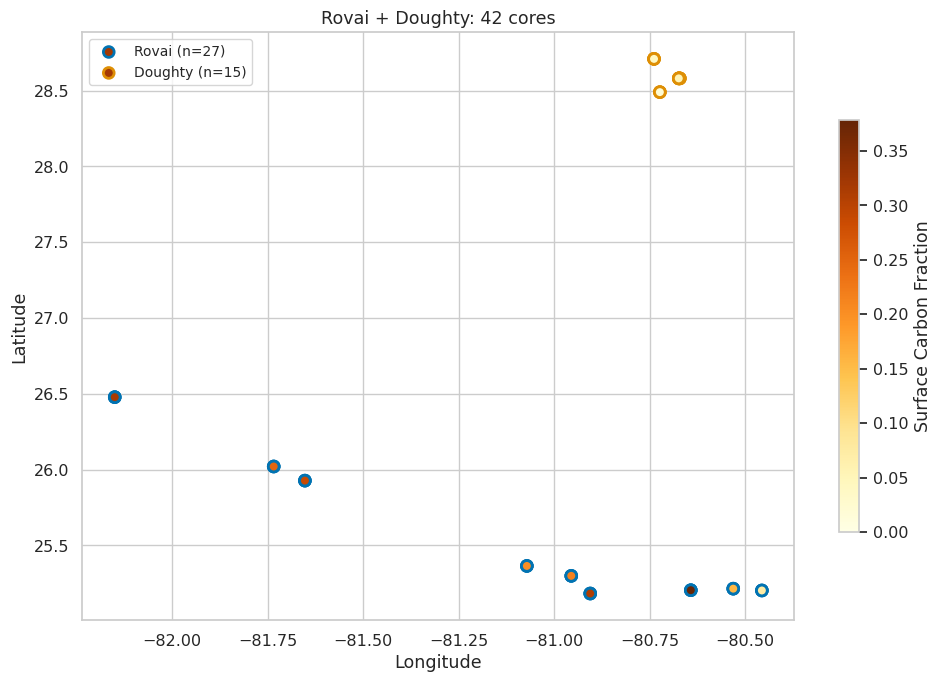

In [6]:
# ── Aggregate surface carbon per core ──

MAX_DEPTH_CM = 30

surface = ds[
    (ds['depth_max'].notna()) & (ds['depth_max'] <= MAX_DEPTH_CM)
].copy()
surface['thickness'] = surface['depth_max'] - surface['depth_min']
surface = surface[surface['thickness'] > 0]

rows = []
for (sid, cid), grp in surface.groupby(['study_id', 'core_id']):
    row = {'study_id': sid, 'core_id': cid}
    for col, out_name in [('fraction_carbon', 'frac_carbon_surface'),
                           ('fraction_organic_matter', 'frac_om_surface'),
                           ('dry_bulk_density', 'dbd_surface')]:
        sub = grp.dropna(subset=[col])
        if len(sub) > 0:
            row[out_name] = np.average(sub[col], weights=sub['thickness'])
        else:
            row[out_name] = np.nan
    rows.append(row)

agg = pd.DataFrame(rows)
cores_target = cores[['study_id', 'core_id', 'lat', 'lon', 'year']].merge(
    agg, on=['study_id', 'core_id'], how='left'
)
cores_target = cores_target.dropna(subset=['lat', 'lon', 'frac_carbon_surface']).reset_index(drop=True)

print(f"\n── Surface Carbon (top {MAX_DEPTH_CM}cm) ──")
print(f"  Cores with carbon: {len(cores_target)}")
for sid in FOCUS_STUDIES:
    sub = cores_target[cores_target['study_id'] == sid]
    print(f"    {sid}: n={len(sub)}, C=[{sub['frac_carbon_surface'].min():.3f}, "
          f"{sub['frac_carbon_surface'].max():.3f}], mean={sub['frac_carbon_surface'].mean():.3f}")

fig, ax = plt.subplots(figsize=(10, 7))
for sid, color in zip(FOCUS_STUDIES, [PAL[0], PAL[1]]):
    sub = cores_target[cores_target['study_id'] == sid]
    sc = ax.scatter(sub['lon'], sub['lat'], c=sub['frac_carbon_surface'],
                    cmap='YlOrBr', s=60, edgecolors=color, linewidths=2,
                    vmin=0, vmax=cores_target['frac_carbon_surface'].quantile(0.95),
                    label=f"{sid.split('_')[0]} (n={len(sub)})")
plt.colorbar(sc, ax=ax, label='Surface Carbon Fraction', shrink=0.7)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Rovai + Doughty: {len(cores_target)} cores')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [7]:
earthaccess.login(persist=True)
print("Earthdata authenticated")

Enter your Earthdata Login username: reidlewisspace
Enter your Earthdata password: ··········
Earthdata authenticated


In [8]:
BUFFER_DEG = 0.3
lon_min = cores_target['lon'].min() - BUFFER_DEG
lon_max = cores_target['lon'].max() + BUFFER_DEG
lat_min = cores_target['lat'].min() - BUFFER_DEG
lat_max = cores_target['lat'].max() + BUFFER_DEG

print(f"Bounding box: [{lon_min:.2f}, {lat_min:.2f}] → [{lon_max:.2f}, {lat_max:.2f}]")

emit_results = earthaccess.search_data(
    short_name="EMITL2ARFL",
    bounding_box=(lon_min, lat_min, lon_max, lat_max),
    temporal=("2022-08-01", "2025-12-31"),
    count=-1
)

print(f"Found {len(emit_results)} EMIT granules")

Bounding box: [-82.45, 24.88] → [-80.16, 29.01]
Found 323 EMIT granules


In [9]:
# ── Pre-filter by bounding box metadata (instant) ──

def get_granule_bbox(granule):
    try:
        spatial = granule['umm']['SpatialExtent']['HorizontalSpatialDomain']['Geometry']
        if 'BoundingRectangles' in spatial:
            br = spatial['BoundingRectangles'][0]
            return (br['WestBoundingCoordinate'], br['SouthBoundingCoordinate'],
                    br['EastBoundingCoordinate'], br['NorthBoundingCoordinate'])
        elif 'GPolygons' in spatial:
            pts = spatial['GPolygons'][0]['Boundary']['Points']
            lons = [p['Longitude'] for p in pts]
            lats = [p['Latitude'] for p in pts]
            return (min(lons), min(lats), max(lons), max(lats))
    except:
        pass
    return None

target_lats = cores_target['lat'].values
target_lons = cores_target['lon'].values

print(f"Pre-filtering {len(emit_results)} scenes...")
candidates = []
for i, granule in enumerate(emit_results):
    bbox = get_granule_bbox(granule)
    if bbox is None:
        candidates.append((i, granule))
        continue
    w, s, e, n = bbox
    if np.any((target_lats >= s - 0.01) & (target_lats <= n + 0.01) &
              (target_lons >= w - 0.01) & (target_lons <= e + 0.01)):
        candidates.append((i, granule))

print(f"  → {len(candidates)} scenes overlap core locations")
print(f"  → Skipping {len(emit_results) - len(candidates)} non-overlapping")

Pre-filtering 323 scenes...
  → 124 scenes overlap core locations
  → Skipping 199 non-overlapping


In [10]:
# ── Download-and-delete extraction (fast local reads) ──

WORK_DIR = '/content/emit_tmp'
os.makedirs(WORK_DIR, exist_ok=True)

def extract_spectra_download(granule, target_lats, target_lons,
                              search_radius_deg=0.003):
    try:
        downloaded = earthaccess.download([granule], WORK_DIR)
        if not downloaded:
            return pd.DataFrame()

        rfl_file = None
        for f in downloaded:
            fname = os.path.basename(f) if isinstance(f, str) else str(f)
            if 'RFL' in fname.upper() and 'MASK' not in fname.upper() and 'UNCERT' not in fname.upper():
                rfl_file = f if isinstance(f, str) else str(f)
                break

        if rfl_file is None or not os.path.exists(rfl_file):
            for f in downloaded:
                fp = f if isinstance(f, str) else str(f)
                if os.path.exists(fp): os.remove(fp)
            return pd.DataFrame()

        ds_rfl = xr.open_dataset(rfl_file)
        ds_loc = xr.open_dataset(rfl_file, group='location')
        ds_wvl = xr.open_dataset(rfl_file, group='sensor_band_parameters')

        refl = ds_rfl['reflectance'].values
        lat  = ds_loc['lat'].values
        lon  = ds_loc['lon'].values
        wavelengths = ds_wvl['wavelengths'].values

        core_in_scene = (
            (target_lats >= np.nanmin(lat) - search_radius_deg) &
            (target_lats <= np.nanmax(lat) + search_radius_deg) &
            (target_lons >= np.nanmin(lon) - search_radius_deg) &
            (target_lons <= np.nanmax(lon) + search_radius_deg)
        )

        results = []
        if core_in_scene.sum() > 0:
            flat_lat = lat.ravel()
            flat_lon = lon.ravel()
            valid_mask = np.isfinite(flat_lat) & np.isfinite(flat_lon)
            valid_idx = np.where(valid_mask)[0]

            if len(valid_idx) > 0:
                tree = cKDTree(np.column_stack([flat_lat[valid_idx], flat_lon[valid_idx]]))
                ncols = lat.shape[1]

                for i in range(len(target_lats)):
                    if not core_in_scene[i]: continue
                    dist, idx = tree.query([target_lats[i], target_lons[i]])
                    if dist > search_radius_deg: continue

                    flat_pos = valid_idx[idx]
                    r = flat_pos // ncols
                    c = flat_pos % ncols
                    spectrum = refl[r, c, :]
                    if np.all(spectrum == -9999) or np.all(spectrum < -0.05): continue

                    r_lo, r_hi = max(0, r-1), min(lat.shape[0], r+2)
                    c_lo, c_hi = max(0, c-1), min(lat.shape[1], c+2)
                    nbr = refl[r_lo:r_hi, c_lo:c_hi, :]
                    nbr = np.where(nbr == -9999, np.nan, nbr)
                    spectrum_3x3 = np.nanmean(nbr, axis=(0, 1))

                    row = {'target_idx': i, 'matched_lat': flat_lat[valid_idx[idx]],
                           'matched_lon': flat_lon[valid_idx[idx]], 'dist_m': dist * 111_000}
                    for b in range(len(wavelengths)):
                        row[f'band_{b}'] = spectrum[b]
                    for b in range(len(wavelengths)):
                        row[f'avg3x3_band_{b}'] = spectrum_3x3[b]
                    results.append(row)

        ds_rfl.close(); ds_loc.close(); ds_wvl.close()
        for f in downloaded:
            fp = f if isinstance(f, str) else str(f)
            if os.path.exists(fp): os.remove(fp)

        return pd.DataFrame(results)

    except Exception as e:
        for f in glob.glob(f'{WORK_DIR}/*'):
            try: os.remove(f)
            except: pass
        return pd.DataFrame()

print("Extraction function defined")

Extraction function defined


In [11]:
# ── Process all candidate scenes ──

all_spectra = []
scene_log = []
n_with_matches = 0
total_matches = 0

print(f"Processing {len(candidates)} scenes (download → extract → delete)...")
print(f"Target: {len(cores_target)} core locations")
print(f"{'─' * 60}")

t0 = time.time()

for j, (i, granule) in enumerate(candidates):
    elapsed = time.time() - t0
    rate = (j + 1) / elapsed if elapsed > 0 else 0
    eta = (len(candidates) - j - 1) / rate / 60 if rate > 0 else 0

    if (j + 1) % 3 == 0 or j == 0:
        print(f"  [{j+1:3d}/{len(candidates)}] matches: {total_matches} "
              f"from {n_with_matches} scenes | ~{eta:.1f} min left")

    spectra = extract_spectra_download(granule, target_lats, target_lons)

    if spectra is not None and len(spectra) > 0:
        try:
            scene_id = granule['meta']['concept-id']
        except:
            scene_id = f'scene_{i}'
        spectra['scene_idx'] = i
        spectra['scene_id'] = scene_id
        all_spectra.append(spectra)
        n_with_matches += 1
        total_matches += len(spectra)
        scene_log.append({'scene_idx': i, 'scene_id': scene_id, 'n_matches': len(spectra)})

elapsed = time.time() - t0
print(f"{'─' * 60}")
print(f"Done in {elapsed / 60:.1f} min")
print(f"   Scenes with matches: {n_with_matches}")
print(f"   Total core-scene matches: {total_matches}")
if all_spectra:
    unique_cores = len(set().union(*[set(s['target_idx']) for s in all_spectra]))
    print(f"   Unique cores matched: {unique_cores} / {len(cores_target)}")

for f in glob.glob(f'{WORK_DIR}/*'):
    try: os.remove(f)
    except: pass

Processing 124 scenes (download → extract → delete)...
Target: 42 core locations
────────────────────────────────────────────────────────────
  [  1/124] matches: 0 from 0 scenes | ~0.0 min left


QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

...

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

  [ 30/124] matches: 147 from 20 scenes | ~158.3 min left


QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ── Combine & deduplicate ──

if not all_spectra:
    raise RuntimeError("No matches found!")

spectra_all = pd.concat(all_spectra, ignore_index=True)
print(f"Raw matches: {len(spectra_all)} (core × scene)")
print(f"Unique cores: {spectra_all['target_idx'].nunique()}")

# Multi-temporal average per core (more stable spectra)
band_cols = [c for c in spectra_all.columns if c.startswith('band_') and not c.startswith('avg')]
avg3x3_cols = [c for c in spectra_all.columns if c.startswith('avg3x3_')]

spectra_tavg = (
    spectra_all
    .groupby('target_idx')[band_cols + avg3x3_cols + ['dist_m']]
    .mean()
    .reset_index()
)
spectra_tavg['n_scenes'] = spectra_all.groupby('target_idx').size().values

print(f"\nTemporal average: {len(spectra_tavg)} cores")
print(f"  Scenes per core: min={spectra_tavg['n_scenes'].min()}, "
      f"max={spectra_tavg['n_scenes'].max()}, mean={spectra_tavg['n_scenes'].mean():.1f}")

# ── Merge with targets ──
merged = cores_target.iloc[spectra_tavg['target_idx'].values].reset_index(drop=True)
for col in band_cols + avg3x3_cols + ['dist_m', 'n_scenes']:
    merged[col] = spectra_tavg[col].values

merged = merged.dropna(subset=['frac_carbon_surface']).reset_index(drop=True)
print(f"\nFinal dataset: {len(merged)} cores with carbon + spectra")
for sid in FOCUS_STUDIES:
    n = (merged['study_id'] == sid).sum()
    print(f"  {sid}: n={n}")

In [ ]:
# ── Remove water absorption bands ──

bad_ranges = [(1320, 1450), (1770, 1970)]
good_bands = []
good_wvls = []
for bc in band_cols:
    bnum = int(bc.split('_')[1])
    wvl = 381 + bnum * 7.4
    if not any(lo <= wvl <= hi for lo, hi in bad_ranges):
        good_bands.append(bc)
        good_wvls.append(wvl)

good_wvls = np.array(good_wvls)
print(f"Usable bands: {len(good_bands)} (removed {len(band_cols) - len(good_bands)} H₂O bands)")

In [ ]:
# ── Spectroscopic preprocessing ──

raw_spectra = merged[good_bands].values
y = merged['frac_carbon_surface'].values
groups = merged['study_id'].values

def snv_transform(spectra):
    """Standard Normal Variate — removes site-to-site brightness shifts."""
    mean = spectra.mean(axis=1, keepdims=True)
    std  = spectra.std(axis=1, keepdims=True)
    std[std == 0] = 1
    return (spectra - mean) / std

def savgol_smooth(spectra, window=11, polyorder=2):
    return np.apply_along_axis(
        lambda x: savgol_filter(x, window, polyorder), axis=1, arr=spectra
    )

def first_derivative(spectra, spacing=7.4):
    """Removes additive baseline, highlights absorption edges."""
    return np.gradient(spectra, spacing, axis=1)

def second_derivative(spectra, spacing=7.4):
    """Removes linear baseline, isolates absorption features."""
    return np.gradient(np.gradient(spectra, spacing, axis=1), spacing, axis=1)

def continuum_removal(spectra, wavelengths):
    """Normalizes to convex hull — isolates absorption depth."""
    from scipy.spatial import ConvexHull
    result = np.zeros_like(spectra)
    for i in range(spectra.shape[0]):
        y_s = spectra[i]
        try:
            points = np.column_stack([wavelengths, y_s])
            hull = ConvexHull(points)
            hull_pts = sorted(set(hull.vertices))
            continuum = np.interp(wavelengths, wavelengths[hull_pts], y_s[hull_pts])
            continuum[continuum == 0] = 1e-8
            result[i] = y_s / continuum
        except:
            result[i] = y_s
    return result

# Build all variants
smoothed = savgol_smooth(raw_spectra)
snv      = snv_transform(smoothed)
d1       = first_derivative(smoothed)
d2       = second_derivative(smoothed)
cr       = continuum_removal(smoothed, good_wvls)

print(f"Built 5 preprocessing variants for {len(y)} samples × {len(good_bands)} bands")

In [ ]:
# ── Physics-based features ──

def band_idx(nm):
    return np.argmin(np.abs(good_wvls - nm))

def absorption_depth(spectra, center_nm, shoulder_left_nm, shoulder_right_nm):
    ci = band_idx(center_nm)
    li = band_idx(shoulder_left_nm)
    ri = band_idx(shoulder_right_nm)
    frac = (good_wvls[ci] - good_wvls[li]) / (good_wvls[ri] - good_wvls[li] + 1e-8)
    continuum = spectra[:, li] + frac * (spectra[:, ri] - spectra[:, li])
    return 1.0 - spectra[:, ci] / (continuum + 1e-8)

# Absorption depth features at known organic carbon wavelengths
abs_names = ['abs_chl', 'abs_cell', 'abs_lignin', 'abs_oc_2300', 'abs_water', 'abs_protein']
abs_feats = np.column_stack([
    absorption_depth(smoothed, 680, 630, 750),     # chlorophyll
    absorption_depth(smoothed, 2100, 2000, 2200),   # cellulose
    absorption_depth(smoothed, 1730, 1680, 1780),   # lignin
    absorption_depth(smoothed, 2300, 2230, 2380),   # organic C
    absorption_depth(smoothed, 970, 920, 1050),     # water
    absorption_depth(smoothed, 2060, 2000, 2120),   # protein
])

# Band ratios (cancel brightness, transfer across sites)
key_wvls = [500, 660, 700, 740, 858, 970, 1240, 1680, 2100, 2200, 2300]
ratio_feats = {}
for w1, w2 in combinations(key_wvls, 2):
    i1, i2 = band_idx(w1), band_idx(w2)
    ratio_feats[f'r_{w1}_{w2}'] = smoothed[:, i1] / (smoothed[:, i2] + 1e-8)
ratio_arr = np.column_stack(list(ratio_feats.values()))

# Simple vegetation/soil indices
def bx(nm): return f'band_{max(0, min(int(round((nm - 381) / 7.4)), 284))}'
nir_col = bx(858); red_col = bx(660); swir_col = bx(1240)

idx_feats = np.column_stack([
    (merged[nir_col] - merged[red_col]) / (merged[nir_col] + merged[red_col] + 1e-8),  # NDVI
    (merged[nir_col] - merged[swir_col]) / (merged[nir_col] + merged[swir_col] + 1e-8), # NDWI
    merged[bx(2300)].values - merged[bx(2350)].values,  # SWIR carbon
])
idx_names = ['NDVI', 'NDWI', 'swir_carbon']

print(f"Absorption features: {abs_feats.shape[1]}")
print(f"Band ratios: {ratio_arr.shape[1]}")
print(f"Vegetation indices: {idx_feats.shape[1]}")

In [ ]:
# ── Feature configs to test ──

X_options = {
    'Raw':           raw_spectra,
    'SNV':           snv,
    '1st deriv':     d1,
    '2nd deriv':     d2,
    'Cont removed':  cr,
    'Abs only':      abs_feats,
    'Ratios only':   ratio_arr,
    'Abs+ratios':    np.hstack([abs_feats, ratio_arr]),
    'SNV+abs':       np.hstack([snv, abs_feats]),
    'd2+abs':        np.hstack([d2, abs_feats]),
    'SNV+abs+ratio': np.hstack([snv, abs_feats, ratio_arr]),
    'd2+abs+ratio':  np.hstack([d2, abs_feats, ratio_arr]),
    'd1+abs':        np.hstack([d1, abs_feats]),
    'CR+abs':        np.hstack([cr, abs_feats]),
}

model_defs = {
    'PLSR-1': lambda: PLSRegression(n_components=1, scale=True),
    'PLSR-2': lambda: PLSRegression(n_components=2, scale=True),
    'PLSR-3': lambda: PLSRegression(n_components=3, scale=True),
    'PLSR-5': lambda: PLSRegression(n_components=5, scale=True),
    'RF':     lambda: RandomForestRegressor(n_estimators=300, max_depth=4,
                min_samples_leaf=3, max_features=0.3, random_state=42),
}

loo = LeaveOneOut()

# ═══════════════════════════════════════════════════════════════
#  LOO CROSS-VALIDATION
# ═══════════════════════════════════════════════════════════════

print(f"{'═' * 70}")
print(f"  LOO CROSS-VALIDATION (n={len(y)})")
print(f"{'═' * 70}\n")
print(f"{'Features':<18s} {'Model':<8s} {'R²':>7s} {'RMSE':>8s} {'MAE':>8s}")
print('─' * 55)

all_loo = []
for fname, X_feat in X_options.items():
    ok = np.isfinite(X_feat).all(axis=1)
    X_ok, y_ok, g_ok = X_feat[ok], y[ok], groups[ok]
    if len(y_ok) < 10: continue

    for mname, mfn in model_defs.items():
        preds = np.zeros(len(y_ok))
        for tr, te in loo.split(X_ok):
            m = mfn()
            m.fit(X_ok[tr], y_ok[tr])
            p = m.predict(X_ok[te])
            preds[te] = p.ravel() if p.ndim > 1 else p

        r2   = r2_score(y_ok, preds)
        rmse = np.sqrt(mean_squared_error(y_ok, preds))
        mae  = mean_absolute_error(y_ok, preds)
        all_loo.append({
            'features': fname, 'model': mname,
            'r2': r2, 'rmse': rmse, 'mae': mae,
            'preds': preds, 'y_true': y_ok, 'groups': g_ok,
        })

all_loo.sort(key=lambda x: x['r2'], reverse=True)
for row in all_loo[:20]:
    flag = ' ◄' if row['r2'] == all_loo[0]['r2'] else ''
    print(f"  {row['features']:<16s} {row['model']:<8s} {row['r2']:+.3f}  "
          f"{row['rmse']:.4f}  {row['mae']:.4f}{flag}")

best_loo = all_loo[0]
print(f"\n  → Best LOO: {best_loo['features']}+{best_loo['model']} "
      f"R²={best_loo['r2']:.3f}")

In [ ]:
# ═══════════════════════════════════════════════════════════════
#  LEAVE-ONE-STUDY-OUT
#  Train on Rovai → test on Doughty (and vice versa)
#  This is the hardest test: can the model transfer?
# ═══════════════════════════════════════════════════════════════

loso_splits = [
    (np.where(groups != s)[0], np.where(groups == s)[0])
    for s in FOCUS_STUDIES
]

print(f"\n{'═' * 70}")
print(f"  LEAVE-ONE-STUDY-OUT (train on one, test on the other)")
print(f"{'═' * 70}\n")

all_loso = []
for fname, X_feat in X_options.items():
    ok = np.isfinite(X_feat).all(axis=1)
    X_ok, y_ok, g_ok = X_feat[ok], y[ok], groups[ok]
    if len(y_ok) < 10: continue

    for mname, mfn in model_defs.items():
        preds = np.zeros(len(y_ok))
        for tr_idx, te_idx in loso_splits:
            # Filter to valid indices
            tr_ok = [i for i in tr_idx if ok[i] if i < len(ok)] if len(tr_idx) > 0 else tr_idx
            te_ok = [i for i in te_idx if ok[i] if i < len(ok)] if len(te_idx) > 0 else te_idx
            m = mfn()
            m.fit(X_feat[tr_ok], y[tr_ok])
            p = m.predict(X_feat[te_ok])
            preds[te_ok] = p.ravel() if p.ndim > 1 else p

        r2 = r2_score(y_ok, preds)
        rmse = np.sqrt(mean_squared_error(y_ok, preds))
        all_loso.append({
            'features': fname, 'model': mname,
            'r2': r2, 'rmse': rmse,
            'preds': preds, 'y_true': y_ok, 'groups': g_ok,
        })

all_loso.sort(key=lambda x: x['r2'], reverse=True)

print(f"{'Features':<18s} {'Model':<8s} {'R²':>7s} {'RMSE':>8s}")
print('─' * 45)
for row in all_loso[:15]:
    flag = ' ◄' if row['r2'] == all_loso[0]['r2'] else ''
    print(f"  {row['features']:<16s} {row['model']:<8s} {row['r2']:+.3f}  {row['rmse']:.4f}{flag}")

best_loso = all_loso[0]

# Per-study breakdown
print(f"\n  Best LOSO: {best_loso['features']}+{best_loso['model']}")
for sid in FOCUS_STUDIES:
    mask = best_loso['groups'] == sid
    r2_s = r2_score(best_loso['y_true'][mask], best_loso['preds'][mask])
    print(f"    Train on other → test {sid.split('_')[0]}: R²={r2_s:+.3f}")

In [ ]:
# ═══════════════════════════════════════════════════════════════
#  FEW-SHOT: give model 2 samples from the test study
#  Most realistic scenario for a new mangrove site
# ═══════════════════════════════════════════════════════════════

print(f"\n{'═' * 70}")
print(f"  FEW-SHOT: leave-one-study-out + 2 calibration samples")
print(f"{'═' * 70}\n")

# Test top 5 feature sets from LOO
top_feats = list(dict.fromkeys([r['features'] for r in all_loo[:10]]))
top_models = list(dict.fromkeys([r['model'] for r in all_loo[:10]]))

all_fewshot = []
N_TRANSFER = 2  # labeled samples from test study
N_REPEATS = 20  # average over random picks

for fname in top_feats[:6]:
    X_feat = X_options[fname]
    ok = np.isfinite(X_feat).all(axis=1)
    X_ok, y_ok, g_ok = X_feat[ok], y[ok], groups[ok]

    for mname in top_models[:3]:
        mfn = model_defs[mname]
        r2_runs = []

        for seed in range(N_REPEATS):
            preds = np.full(len(y_ok), np.nan)
            rng = np.random.RandomState(seed)

            for test_study in FOCUS_STUDIES:
                test_mask = g_ok == test_study
                train_mask = ~test_mask
                test_indices = np.where(test_mask)[0]
                if len(test_indices) < N_TRANSFER + 2: continue

                transfer_idx = rng.choice(test_indices, size=N_TRANSFER, replace=False)
                true_test = np.array([i for i in test_indices if i not in transfer_idx])

                train_expanded = np.concatenate([np.where(train_mask)[0], transfer_idx])
                m = mfn()
                m.fit(X_ok[train_expanded], y_ok[train_expanded])
                preds[true_test] = m.predict(X_ok[true_test]).ravel() if hasattr(m.predict(X_ok[true_test:true_test+1]), 'ravel') else m.predict(X_ok[true_test])

            valid = ~np.isnan(preds)
            if valid.sum() > 5:
                r2_runs.append(r2_score(y_ok[valid], preds[valid]))

        if r2_runs:
            mean_r2 = np.mean(r2_runs)
            std_r2 = np.std(r2_runs)
            all_fewshot.append({
                'features': fname, 'model': mname,
                'r2_mean': mean_r2, 'r2_std': std_r2,
            })

all_fewshot.sort(key=lambda x: x['r2_mean'], reverse=True)
print(f"{'Features':<18s} {'Model':<8s} {'R² mean':>8s} {'± std':>7s}")
print('─' * 48)
for row in all_fewshot[:10]:
    flag = ' ◄' if row['r2_mean'] == all_fewshot[0]['r2_mean'] else ''
    print(f"  {row['features']:<16s} {row['model']:<8s} {row['r2_mean']:+.3f}   "
          f"±{row['r2_std']:.3f}{flag}")

In [ ]:
# ── 6a. LOO + LOSO pred vs obs side by side ──

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (label, best) in zip(axes[:2],
    [('LOO', best_loo), ('Leave-one-study-out', best_loso)]):

    yt, yp, gp = best['y_true'], best['preds'], best['groups']
    for sid, color in zip(FOCUS_STUDIES, [PAL[0], PAL[1]]):
        mask = gp == sid
        ax.scatter(yt[mask], yp[mask], s=60, alpha=0.7, color=color,
                   edgecolors='black', linewidths=0.5,
                   label=f"{sid.split('_')[0]} (n={mask.sum()})")
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    margin = (lims[1] - lims[0]) * 0.08
    lims = [lims[0] - margin, lims[1] + margin]
    ax.plot(lims, lims, 'k--', alpha=0.4)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Observed'); ax.set_ylabel('Predicted')
    ax.set_title(f"{label}\n{best['features']}+{best['model']}: R²={best['r2']:.3f}")
    ax.legend(fontsize=9)
    ax.set_aspect('equal')

# Heatmap: top feature × model combos
ax = axes[2]
loo_df = pd.DataFrame([{k: v for k, v in r.items()
    if k in ['features', 'model', 'r2']} for r in all_loo])
pivot = loo_df.pivot_table(index='features', columns='model', values='r2')
pivot = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index[:10]]
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            vmin=-0.3, vmax=0.8, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'LOO R²'})
ax.set_title('Feature × Model LOO R²')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
# ── 6b. Per-band correlation by study (SNV) ──

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Per-study correlation profiles
ax = axes[0]
for sid, color in zip(FOCUS_STUDIES, [PAL[0], PAL[1]]):
    mask = groups == sid
    corrs = [pearsonr(snv[mask, i], y[mask])[0] for i in range(len(good_bands))]
    ax.plot(good_wvls, corrs, color=color, linewidth=1.5,
            label=f"{sid.split('_')[0]} (n={mask.sum()})")
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_ylabel('Pearson r with carbon')
ax.set_title('Per-band correlation (SNV preprocessed) by study')
ax.legend(fontsize=10)
ax.set_xlim(380, 2500)
for lo, hi in [(1320, 1450), (1770, 1970)]:
    ax.axvspan(lo, hi, alpha=0.08, color='gray')

# Combined
ax = axes[1]
corrs = [pearsonr(snv[:, i], y)[0] for i in range(len(good_bands))]
ax.plot(good_wvls, corrs, color='black', linewidth=1.5)
ax.fill_between(good_wvls, 0, corrs,
                where=np.array(corrs) > 0, color=PAL[3], alpha=0.3)
ax.fill_between(good_wvls, 0, corrs,
                where=np.array(corrs) < 0, color=PAL[0], alpha=0.3)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('Pearson r')
ax.set_title('Combined per-band correlation (both studies)')
ax.set_xlim(380, 2500)
for lo, hi in [(1320, 1450), (1770, 1970)]:
    ax.axvspan(lo, hi, alpha=0.08, color='gray')

plt.tight_layout()
plt.show()

In [ ]:
# ── 6c. Spectra by carbon tercile + PLSR loadings ──

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Spectra colored by carbon
ax = axes[0, 0]
norm = plt.Normalize(y.min(), y.max())
cmap = plt.cm.YlOrBr
for i in range(len(y)):
    ax.plot(good_wvls, snv[i], color=cmap(norm(y[i])), alpha=0.5, linewidth=0.8)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='Frac C')
ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('SNV Reflectance')
ax.set_title('SNV spectra colored by carbon')

# Carbon tercile mean spectra
ax = axes[0, 1]
q33 = np.percentile(y, 33)
q66 = np.percentile(y, 66)
for label, mask, color in [
    (f'Low (<{q33:.2f})', y <= q33, PAL[2]),
    (f'Mid ({q33:.2f}–{q66:.2f})', (y > q33) & (y <= q66), PAL[1]),
    (f'High (>{q66:.2f})', y > q66, PAL[3]),
]:
    mean_s = snv[mask].mean(axis=0)
    std_s = snv[mask].std(axis=0)
    ax.plot(good_wvls, mean_s, color=color, linewidth=2, label=f'{label} (n={mask.sum()})')
    ax.fill_between(good_wvls, mean_s - std_s, mean_s + std_s, alpha=0.1, color=color)
ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('SNV Reflectance')
ax.set_title('Mean SNV spectra by carbon tercile')
ax.legend(fontsize=9)

# PLSR loadings from best LOO
ax = axes[1, 0]
X_best = X_options[best_loo['features']]
n_comp = int(best_loo['model'].split('-')[1]) if 'PLSR' in best_loo['model'] else 3
pls_final = PLSRegression(n_components=n_comp, scale=True)
pls_final.fit(X_best, y)
coefs = pls_final.coef_.ravel()[:len(good_bands)]
ax.plot(good_wvls, coefs, color='black', linewidth=1.2)
ax.fill_between(good_wvls, 0, coefs, where=coefs > 0, color=PAL[3], alpha=0.3, label='+ carbon')
ax.fill_between(good_wvls, 0, coefs, where=coefs < 0, color=PAL[0], alpha=0.3, label='− carbon')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('PLSR coefficient')
ax.set_title(f'PLSR loadings ({best_loo["features"]}, {n_comp} comp)')
ax.legend(fontsize=9)
ax.set_xlim(380, 2500)

# Absorption feature correlations
ax = axes[1, 1]
abs_corrs = {name: pearsonr(abs_feats[:, i], y)[0] for i, name in enumerate(abs_names)}
abs_s = pd.Series(abs_corrs).sort_values()
colors = [PAL[3] if v > 0 else PAL[0] for v in abs_s.values]
ax.barh(range(len(abs_s)), abs_s.values, color=colors, edgecolor='black', linewidth=0.3)
ax.set_yticks(range(len(abs_s)))
ax.set_yticklabels(abs_s.index, fontsize=10)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Pearson r with carbon')
ax.set_title('Absorption feature correlations')
ax.invert_yaxis()

plt.suptitle(f'Rovai + Doughty: {len(y)} cores', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ── 6d. PCA: spectral structure vs carbon ──

pca = PCA(n_components=3).fit(snv)
pcs = pca.transform(snv)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PC1 vs PC2 colored by carbon
ax = axes[0]
sc = ax.scatter(pcs[:, 0], pcs[:, 1], c=y, cmap='YlOrBr', s=60,
                edgecolors='black', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='Frac C')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Spectral PCA — colored by carbon')

# PC1 vs PC2 colored by study
ax = axes[1]
for sid, color in zip(FOCUS_STUDIES, [PAL[0], PAL[1]]):
    mask = groups == sid
    ax.scatter(pcs[mask, 0], pcs[mask, 1], s=60, color=color,
               edgecolors='black', linewidths=0.5, label=sid.split('_')[0])
ax.set_xlabel(f'PC1'); ax.set_ylabel(f'PC2')
ax.set_title('Spectral PCA — colored by study')
ax.legend(fontsize=10)

# PC1 vs carbon
ax = axes[2]
for sid, color in zip(FOCUS_STUDIES, [PAL[0], PAL[1]]):
    mask = groups == sid
    ax.scatter(pcs[mask, 0], y[mask], s=60, color=color,
               edgecolors='black', linewidths=0.5, label=sid.split('_')[0])
r_pc1 = pearsonr(pcs[:, 0], y)[0]
ax.set_xlabel(f'PC1'); ax.set_ylabel('Frac Carbon')
ax.set_title(f'PC1 vs Carbon (r={r_pc1:.3f})')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ── Summary ──

print(f"{'═' * 65}")
print(f"  FINAL RESULTS — Rovai + Doughty")
print(f"{'═' * 65}")
print(f"  Samples: {len(y)} ({(groups==FOCUS_STUDIES[0]).sum()} Rovai + "
      f"{(groups==FOCUS_STUDIES[1]).sum()} Doughty)")
print(f"  Carbon range: [{y.min():.3f}, {y.max():.3f}]")
print(f"")
print(f"  LOO best:      {best_loo['features']}+{best_loo['model']} "
      f"→ R²={best_loo['r2']:.3f}, RMSE={best_loo['rmse']:.4f}")
print(f"  LOSO best:     {best_loso['features']}+{best_loso['model']} "
      f"→ R²={best_loso['r2']:.3f}, RMSE={best_loso['rmse']:.4f}")
if all_fewshot:
    fs = all_fewshot[0]
    print(f"  Few-shot best: {fs['features']}+{fs['model']} "
          f"→ R²={fs['r2_mean']:.3f} ± {fs['r2_std']:.3f}")
print(f"{'═' * 65}")

In [ ]:
# ── Export ──

out_dir = '/content/drive/MyDrive/EMIT_CCN_v3'
os.makedirs(out_dir, exist_ok=True)

# Save merged dataset
merged.to_csv(f'{out_dir}/rovai_doughty_merged.csv', index=False)

# Save all scene matches (multi-temporal)
if all_spectra:
    pd.concat(all_spectra, ignore_index=True).to_csv(
        f'{out_dir}/all_scene_matches.csv', index=False)

# Save LOO results table
loo_export = pd.DataFrame([{k: v for k, v in r.items()
    if k in ['features', 'model', 'r2', 'rmse', 'mae']} for r in all_loo])
loo_export.to_csv(f'{out_dir}/loo_results.csv', index=False)

# Save LOSO results
loso_export = pd.DataFrame([{k: v for k, v in r.items()
    if k in ['features', 'model', 'r2', 'rmse']} for r in all_loso])
loso_export.to_csv(f'{out_dir}/loso_results.csv', index=False)

# Save scene log
pd.DataFrame(scene_log).to_csv(f'{out_dir}/scene_log.csv', index=False)

print(f"Saved to: {out_dir}")
for f in sorted(os.listdir(out_dir)):
    sz = os.path.getsize(os.path.join(out_dir, f)) / (1024**2)
    print(f"   {f}  ({sz:.1f} MB)")